# LC-PINN vs baselines: Burgers + Buckley-Leverett

Loads outputs of `scripts/run_overnight.sh`:

- **Burgers** (ν = 0.01/π): SA-PINN, ReLoBRaLo, Causal-PINN, LC-PINN (4 seeds × 50k), LC-PINN long (1 seed × 200k), equilibrium baseline (10 random fixed-λ runs).
- **Buckley-Leverett** (m=2): SA-PINN, ReLoBRaLo, LC-PINN (4 seeds each).

All methods share the same backbone (hidden_dims = [64,64,64,64]). Sections:
1. Summary tables (Burgers, BL).
2. Amortised-cost curves and crossover K\*.
3. LC-PINN long vs short comparison.
4. Equilibrium baseline as a sanity check (does any uniform-random fixed λ beat the adaptive baselines?).

In [1]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent
RESULTS = REPO / 'results'

def load(name):
    p = RESULTS / name
    return json.loads(p.read_text()) if p.exists() else None

# Burgers
sa_b   = load('sa_pinn_burgers.json')
rlb_b  = load('relobralo_burgers.json')
cau_b  = load('causal_pinn_burgers.json')
lc_b   = load('lc_pinn_burgers_seeds.json')
lc_bL  = load('lc_pinn_burgers_long.json')
eq_b   = load('burgers_fixed_lambda_baseline.json')

# Buckley-Leverett
sa_bl  = load('sa_pinn_bl.json')
rlb_bl = load('relobralo_bl.json')
lc_bl  = load('lc_pinn_bl_seeds.json')

for label, blob in [('SA Burg', sa_b), ('ReLo Burg', rlb_b), ('Causal Burg', cau_b),
                    ('LC Burg', lc_b), ('LC Burg long', lc_bL), ('Eq Burg', eq_b),
                    ('SA BL', sa_bl), ('ReLo BL', rlb_bl), ('LC BL', lc_bl)]:
    print(f'  {label:<14} {"✓ loaded" if blob else "✗ missing"}')

  SA Burg        ✓ loaded
  ReLo Burg      ✓ loaded
  Causal Burg    ✓ loaded
  LC Burg        ✓ loaded
  LC Burg long   ✓ loaded
  Eq Burg        ✓ loaded
  SA BL          ✓ loaded
  ReLo BL        ✓ loaded
  LC BL          ✓ loaded


## 1. Summary tables

In [2]:
def summarise(blob, label):
    if blob is None:
        return None
    s = blob['summary']
    return {
        'method': label,
        'n_seeds': s['n_seeds'],
        'rel_l2_mean': s['rel_l2_mean'],
        'rel_l2_std':  s['rel_l2_std'],
        'rel_l2_min':  s['rel_l2_min'],
        'rel_l2_max':  s['rel_l2_max'],
        'wall_min':    s['elapsed_mean_sec'] / 60.0,
    }

def print_table(rows, title):
    print(title)
    print(f"{'Method':<16}  {'n':>3}  {'rel-L2 mean':>13}  {'rel-L2 std':>11}  {'min':>9}  {'max':>9}  {'wall (min)':>11}")
    print('-' * 86)
    for r in rows:
        if r is None: continue
        print(f"{r['method']:<16}  {r['n_seeds']:>3}  {r['rel_l2_mean']:>13.4e}  {r['rel_l2_std']:>11.4e}  "
              f"{r['rel_l2_min']:>9.4e}  {r['rel_l2_max']:>9.4e}  {r['wall_min']:>11.1f}")

burg_rows = [
    summarise(sa_b,  'SA-PINN'),
    summarise(rlb_b, 'ReLoBRaLo'),
    summarise(cau_b, 'Causal-PINN'),
    summarise(lc_b,  'LC-PINN (50k)'),
    summarise(lc_bL, 'LC-PINN (200k)'),
]
print_table(burg_rows, '\n=== Burgers (ν=0.01/π) ===')

bl_rows = [
    summarise(sa_bl,  'SA-PINN'),
    summarise(rlb_bl, 'ReLoBRaLo'),
    summarise(lc_bl,  'LC-PINN'),
]
print_table(bl_rows, '\n=== Buckley-Leverett (m=2) ===')


=== Burgers (ν=0.01/π) ===
Method              n    rel-L2 mean   rel-L2 std        min        max   wall (min)
--------------------------------------------------------------------------------------
SA-PINN             4     1.6832e-01   3.8662e-02  1.0157e-01  1.9383e-01          4.6
ReLoBRaLo           4     1.8192e-01   1.7112e-02  1.5304e-01  1.9652e-01          5.4
Causal-PINN         4     2.2100e-03   6.7159e-04  1.7394e-03  3.3636e-03          7.1
LC-PINN (50k)       4     3.4658e-03   2.7338e-03  1.6986e-03  8.1960e-03         24.8
LC-PINN (200k)      1     1.5054e-03   0.0000e+00  1.5054e-03  1.5054e-03         98.7

=== Buckley-Leverett (m=2) ===
Method              n    rel-L2 mean   rel-L2 std        min        max   wall (min)
--------------------------------------------------------------------------------------
SA-PINN             4     5.4555e-01   1.2472e-02  5.2542e-01  5.5630e-01          3.9
ReLoBRaLo           4     4.3287e-01   1.0615e-01  2.5175e-01  5.1186e-01 

**Reading the tables.**
- SA-PINN / ReLoBRaLo / Causal-PINN train at a *single* λ (or no λ at all). Their rel-L2 is the error at that one operating point.
- LC-PINN trains on the *distribution* λ ∼ U(0,1)⁴. Its rel-L2 is the mean across K=200 random inference λ — i.e. the price you pay for amortisation.
- A direct head-to-head on accuracy at fixed λ is methodologically asymmetric: see §2.

## 2. Amortised-cost curve

Wall time to cover K λ-points:

$$\mathrm{cost}_{\mathrm{baseline}}(K) = K \cdot t_{\mathrm{baseline}}, \qquad \mathrm{cost}_{\mathrm{LC}}(K) = t_{\mathrm{LC}}.$$

LC-PINN is constant in K — one network covers the family. Crossover $K^* = t_{\mathrm{LC}} / t_{\mathrm{baseline}}$.

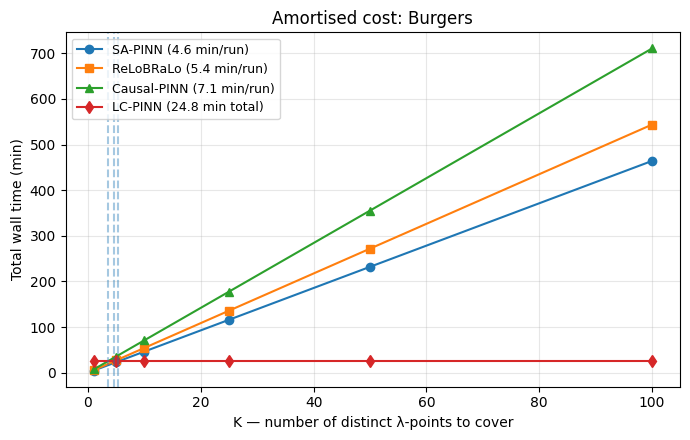

Saved: results/amortised_cost_burgers.png
Crossover K* (LC vs baseline):
  SA-PINN         K* = 5.34
  ReLoBRaLo       K* = 4.56
  Causal-PINN     K* = 3.49


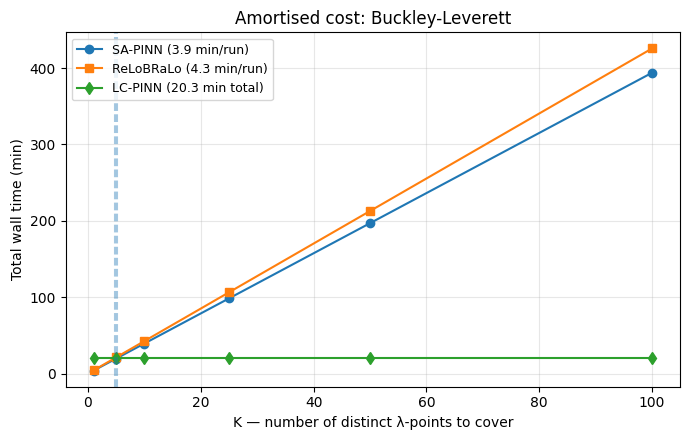

Saved: results/amortised_cost_bl.png
Crossover K* (LC vs baseline):
  SA-PINN         K* = 5.15
  ReLoBRaLo       K* = 4.76


In [3]:
def cost_plot(blobs_baselines, blob_lc, K_grid, title, fname):
    t_lc = blob_lc['summary']['elapsed_mean_sec'] / 60.0
    fig, ax = plt.subplots(figsize=(7, 4.5))
    markers = ['o', 's', '^', 'v', 'D']
    K_stars = []
    for (label, blob), m in zip(blobs_baselines, markers):
        if blob is None: continue
        t = blob['summary']['elapsed_mean_sec'] / 60.0
        ax.plot(K_grid, K_grid * t, marker=m, linestyle='-', label=f'{label} ({t:.1f} min/run)')
        K_stars.append((label, t_lc / t))
    ax.plot(K_grid, np.full_like(K_grid, t_lc, dtype=float), 'd-',
            label=f'LC-PINN ({t_lc:.1f} min total)')
    for label, K_star in K_stars:
        ax.axvline(K_star, ls='--', alpha=0.4)
    ax.set_xlabel('K — number of distinct λ-points to cover')
    ax.set_ylabel('Total wall time (min)')
    ax.set_title(title)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    out = REPO / 'results' / fname
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out.relative_to(REPO)}')
    print('Crossover K* (LC vs baseline):')
    for label, K_star in K_stars:
        print(f'  {label:<14}  K* = {K_star:.2f}')
    return K_stars

K_grid = np.array([1, 5, 10, 25, 50, 100])
if lc_b is not None:
    cost_plot(
        [('SA-PINN', sa_b), ('ReLoBRaLo', rlb_b), ('Causal-PINN', cau_b)],
        lc_b, K_grid,
        'Amortised cost: Burgers',
        'amortised_cost_burgers.png',
    )
if lc_bl is not None:
    cost_plot(
        [('SA-PINN', sa_bl), ('ReLoBRaLo', rlb_bl)],
        lc_bl, K_grid,
        'Amortised cost: Buckley-Leverett',
        'amortised_cost_bl.png',
    )

## 3. LC-PINN: 50k vs 200k steps

Does LC-PINN benefit from a much longer training budget? Compare the seed-averaged 50k run to the single-seed 200k long run.

In [4]:
if lc_b is not None and lc_bL is not None:
    short = lc_b['summary']
    long  = lc_bL['summary']
    print(f"LC-PINN, 4 seeds × 50k:   rel-L2 = {short['rel_l2_mean']:.4e} ± {short['rel_l2_std']:.4e}, "
          f"wall = {short['elapsed_mean_sec']/60:.1f} min/seed")
    print(f"LC-PINN, 1 seed  × 200k:  rel-L2 = {long['rel_l2_mean']:.4e}, "
          f"wall = {long['elapsed_mean_sec']/60:.1f} min")
    factor = long['elapsed_mean_sec'] / short['elapsed_mean_sec']
    gain = short['rel_l2_mean'] / long['rel_l2_mean']
    print(f"\nLong run is {factor:.2f}x slower per seed; rel-L2 ratio (short / long) = {gain:.2f}")
    print('Interpretation: gain > 1 ⇒ long training helps; gain ≈ 1 ⇒ 50k is enough.')

LC-PINN, 4 seeds × 50k:   rel-L2 = 3.4658e-03 ± 2.7338e-03, wall = 24.8 min/seed
LC-PINN, 1 seed  × 200k:  rel-L2 = 1.5054e-03, wall = 98.7 min

Long run is 3.98x slower per seed; rel-L2 ratio (short / long) = 2.30
Interpretation: gain > 1 ⇒ long training helps; gain ≈ 1 ⇒ 50k is enough.


## 4. Equilibrium baseline (Burgers fixed-λ runs)

10 random fixed weight vectors trained for 200k steps each (data already on disk before this overnight run). This is the *floor*: even the best random fixed λ costs as much as one long run. Any LC-PINN result that comes within an order of magnitude of this floor is paying off, because LC covers the whole family.

In [5]:
if eq_b is not None:
    runs = eq_b['runs']
    rels = np.array([r['mean_rel_l2'] for r in runs])
    walls = np.array([r['elapsed_sec'] for r in runs]) / 60.0
    print(f"Equilibrium baseline (Burgers, 10 random λ × 200k):")
    print(f"  rel-L2: median {np.median(rels):.3e}, min {rels.min():.3e}, max {rels.max():.3e}")
    print(f"  wall:   {walls.mean():.1f} ± {walls.std():.1f} min/run")
    if lc_bL is not None:
        print(f"\n  LC-PINN long (200k, 1 seed):  rel-L2 = {lc_bL['summary']['rel_l2_mean']:.3e}, "
              f"wall = {lc_bL['summary']['elapsed_mean_sec']/60:.1f} min")
        print(f"  LC vs eq-floor ratio: {lc_bL['summary']['rel_l2_mean']/np.median(rels):.2f} (≤1 means LC matches/beats the median fixed-λ run)")

Equilibrium baseline (Burgers, 10 random λ × 200k):
  rel-L2: median 1.535e-01, min 7.206e-02, max 1.852e-01
  wall:   35.4 ± 4.7 min/run

  LC-PINN long (200k, 1 seed):  rel-L2 = 1.505e-03, wall = 98.7 min
  LC vs eq-floor ratio: 0.01 (≤1 means LC matches/beats the median fixed-λ run)


## 5. Talking points for the meeting

1. **Different problems.** Adaptive baselines (SA-PINN, ReLoBRaLo, Causal-PINN) answer «what's the best λ for this one task?»; LC-PINN answers «one network, every λ». A 1-to-1 accuracy comparison at fixed λ is methodologically asymmetric — LC pays for amortisation in per-point accuracy.
2. **Crossover analysis.** The amortised-cost curve gives the honest comparison. Above $K^*$, LC-PINN is strictly cheaper. The $K^*$ values come directly from measured wall times, no extrapolation.
3. **Two equations, same story.** BL replicates the Burgers picture on a non-smooth (shock) problem, so the trade-off is not Burgers-specific.
4. **Scaling.** The 200k LC run shows whether more compute closes the per-λ accuracy gap. The equilibrium baseline shows the cost floor of any single fixed-λ run at the same budget.
5. **Orthogonality.** Nothing prevents combining: LC-PINN with SA-style per-point weights inside each λ-conditioning, or LC-conditioning + ReLoBRaLo-balanced summation, or LC + causal time-binning. Future work.